MATERIALS



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

zip_path = "archive.zip"
extract_path = "/content/metal_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Archivos extraídos en:", extract_path)

Archivos extraídos en: /content/metal_dataset


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_path = "/content/metal_dataset/industrial_defect_dataset/train"
val_path = "/content/metal_dataset/industrial_defect_dataset/val"

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Clases:", train_dataset.classes)
print("Total imágenes entrenamiento:", len(train_dataset))
print("Total imágenes validación:", len(val_dataset))

Clases: ['crack', 'hole', 'normal', 'rust', 'scratch']
Total imágenes entrenamiento: 12000
Total imágenes validación: 3000


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Transformaciones
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # Convertir a 3 canales
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Cargar datos
train_dataset = datasets.ImageFolder('/content/metal_dataset/industrial_defect_dataset/train', transform=transform)
val_dataset = datasets.ImageFolder('/content/metal_dataset/industrial_defect_dataset/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Cargar modelo preentrenado
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 5)  # 5 clases

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenamiento básico
for epoch in range(5):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 224MB/s]


Epoch 1, Loss: 0.05555922672439677
Epoch 2, Loss: 0.03222312564996537
Epoch 3, Loss: 0.021739823602154502
Epoch 4, Loss: 0.02585754733103871
Epoch 5, Loss: 0.015565475371559539


ya tenemos un modelo funcional pero esto no nos dice nada con que comparar asi que vamos a adicionar metricas, matriz de confusion y graficas

Epoch 1/5
Train Loss: 0.0570 | Train Acc: 0.9852
Val Acc: 0.9983
----------------------------------------
Epoch 2/5
Train Loss: 0.0277 | Train Acc: 0.9932
Val Acc: 1.0000
----------------------------------------
Epoch 3/5
Train Loss: 0.0100 | Train Acc: 0.9972
Val Acc: 0.9947
----------------------------------------
Epoch 4/5
Train Loss: 0.0448 | Train Acc: 0.9889
Val Acc: 0.9910
----------------------------------------
Epoch 5/5
Train Loss: 0.0113 | Train Acc: 0.9972
Val Acc: 0.9987
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

       crack       1.00      1.00      1.00       600
        hole       1.00      1.00      1.00       600
      normal       1.00      1.00      1.00       600
        rust       1.00      1.00      1.00       600
     scratch       1.00      0.99      1.00       600

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted av

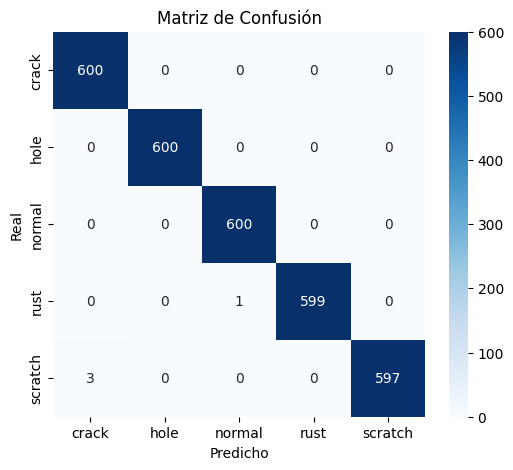

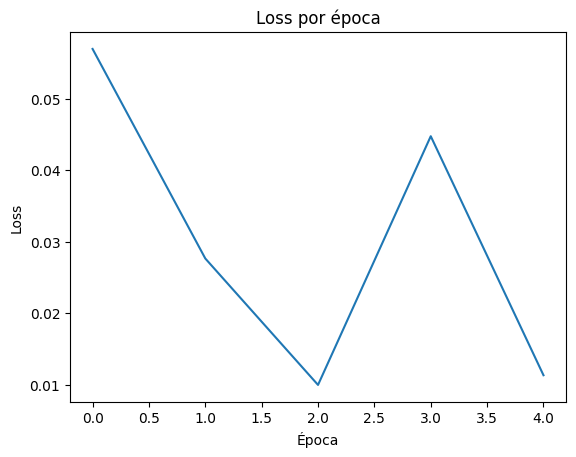

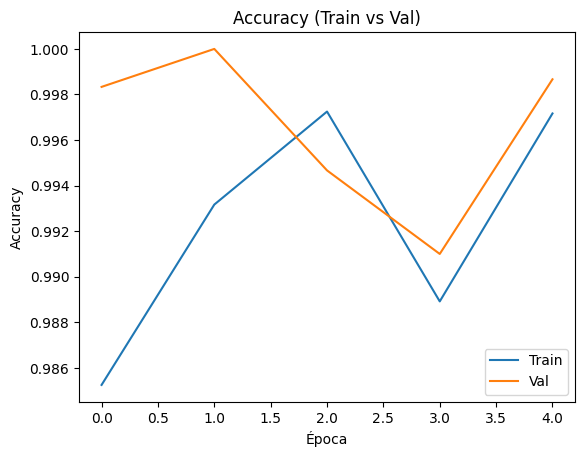

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder('/content/metal_dataset/industrial_defect_dataset/train', transform=transform)
val_dataset = datasets.ImageFolder('/content/metal_dataset/industrial_defect_dataset/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


num_epochs = 5
train_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Acc: {val_acc:.4f}")
    print("-"*40)


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

plt.figure()
plt.plot(train_losses)
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title("Accuracy (Train vs Val)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

MARKET PREDICTION

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd

df_stock = pd.read_csv("Toyota_Stock_Prices_1980_2026.csv")

print(df_stock.head())
print(df_stock.info())
print("Stock shape:", df_stock.shape)

         Date   Close    High     Low    Open  Volume
0  1980-03-18  1.8207  1.8501  1.8207  1.8207    9343
1  1980-03-19  1.8207  1.8207  1.8207  1.8207       0
2  1980-03-20  1.8207  1.8501  1.8207  1.8207   10277
3  1980-03-21  1.8649  1.8944  1.8649  1.8649    8409
4  1980-03-24  1.8723  1.9017  1.8723  1.8723    2803
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    11508 non-null  object 
 1   Close   11508 non-null  float64
 2   High    11508 non-null  float64
 3   Low     11508 non-null  float64
 4   Open    11508 non-null  float64
 5   Volume  11508 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 539.6+ KB
None
Stock shape: (11508, 6)


Dimensiones: (11508, 6)
         Date   Close    High     Low    Open  Volume
0  1980-03-18  1.8207  1.8501  1.8207  1.8207    9343
1  1980-03-19  1.8207  1.8207  1.8207  1.8207       0
2  1980-03-20  1.8207  1.8501  1.8207  1.8207   10277
3  1980-03-21  1.8649  1.8944  1.8649  1.8649    8409
4  1980-03-24  1.8723  1.9017  1.8723  1.8723    2803
=== MÉTRICAS DE REGRESIÓN ===
MAE: 34.71345931841865
MSE: 2437.7984055714164
RMSE: 49.374066123537126
R2: -0.6981212417140585


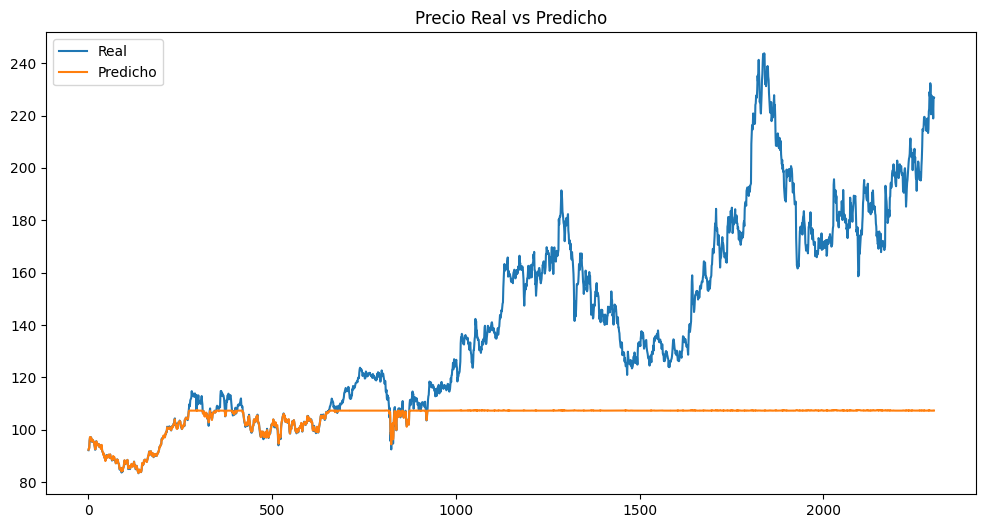

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("Toyota_Stock_Prices_1980_2026.csv")

print("Dimensiones:", df.shape)
print(df.head())

X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Close']

# ⚠️ Para series temporales NO se hace shuffle
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== MÉTRICAS DE REGRESIÓN ===")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred, label="Predicho")
plt.title("Precio Real vs Predicho")
plt.legend()
plt.show()

Tenemos un problema se entrena con datos de los 80 y 90 pero se prueba con datos de 2010 a 2026 lo que genera que el modelo no prediga bien el plano


esto en realidad no es problema del modelo si no de mercado, entonces como solucionamos un problema de mercado..... bueno hagamos preddicion de retornos y no del stock en si mismo asi podemos extrapolar el retorno por accion al valor real de la accion

MAE: 0.011406037737340023
RMSE: 0.015881828772925592
R2: -0.14382886920537308


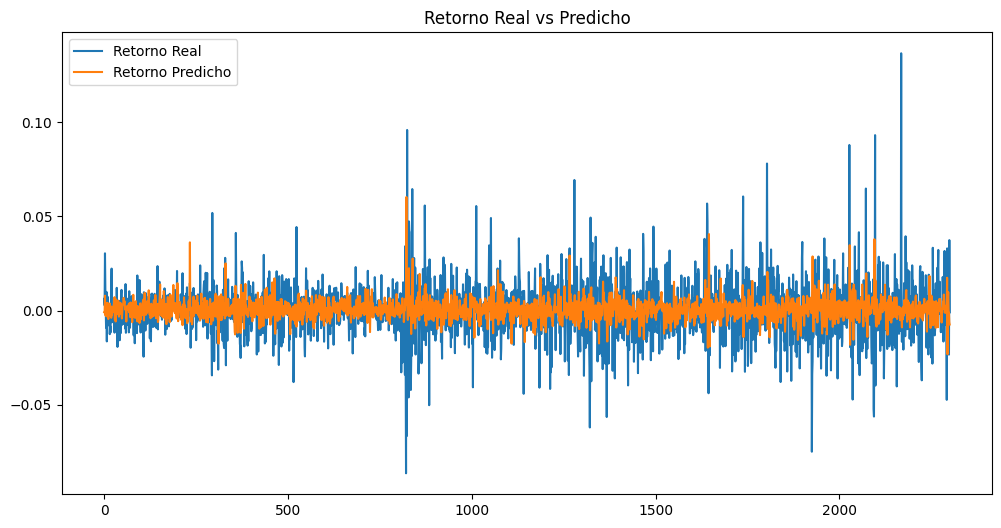

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("Toyota_Stock_Prices_1980_2026.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.sort_values("Date", inplace=True)


df['Return'] = df['Close'].pct_change()

df['Return_lag1'] = df['Return'].shift(1)
df['Return_lag2'] = df['Return'].shift(2)
df['Return_lag3'] = df['Return'].shift(3)

df.dropna(inplace=True)


X = df[['Return_lag1', 'Return_lag2', 'Return_lag3']]
y = df['Return']

split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


last_train_price = df['Close'].iloc[split_index]

predicted_prices = [last_train_price]

for r in y_pred:
    predicted_prices.append(predicted_prices[-1] * (1 + r))

predicted_prices = predicted_prices[1:]


plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Retorno Real")
plt.plot(y_pred, label="Retorno Predicho")
plt.legend()
plt.title("Retorno Real vs Predicho")
plt.show()

LOAN RISK

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving loan_risk_prediction_dataset.csv to loan_risk_prediction_dataset (1).csv


In [ ]:
import pandas as pd

df_loan = pd.read_csv("loan_risk_prediction_dataset.csv")

print(df_loan.head())
print(df_loan.info())
print("Loan shape:", df_loan.shape)

   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age            

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
df = pd.read_csv("loan_risk_prediction_dataset.csv")

print("Dimensiones:", df.shape)
print(df.head())
df.fillna(df.mean(numeric_only=True), inplace=True)

# Categóricos → "Unknown"
df.fillna("Unknown", inplace=True)
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

# Identificar columnas
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

Dimensiones: (5000, 10)
   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0        586.0                6    Male   
2   46  44219.0     26530.0        781.0               26    Male   
3   32  56307.0     11531.0        549.0               11    Male   
4   60  37034.0     27871.0        500.0               19  Female   

     Education           City EmploymentType  LoanApproved  
0  High School        Houston     Unemployed             0  
1  High School  San Francisco  Self-Employed             0  
2          PhD        Houston  Self-Employed             1  
3          NaN       New York     Unemployed             0  
4  High School        Chicago     Unemployed             0  
=== Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91       775
           1       0.64      0.90      0.75       225

 